# Diffusion Model Training with LoRA — Healthy Brain MRI

## Overview
This notebook trains a **2D DDPM diffusion model** on healthy thin-slice T1w brain MRI
using **LoRA (Low-Rank Adaptation)** for parameter-efficient training.
The trained model is then used at inference time for **unsupervised anomaly detection**.

---

## Anomaly Detection Pipeline (inference)

```
Diseased slice  x₀
      │
      ▼
Saliency map from ACAT classifier
      → rough binary mask  M  of 'where pathology probably is'
      │
      ▼
DDIM encode  (forward noising, only inside masked region)
      x_L  =  q(x_L | x₀)   applied only where M = 1
      │
      ▼
Hybrid DDPM + DDIM decode
      ├─ inside  M = 1  →  DDPM steps  (stochastic, free to change pathology)
      └─ outside M = 0  →  DDIM steps  (deterministic, preserves healthy anatomy)
      │
      ▼
Healthy reconstruction  x̂₀
      │
      ▼
Anomaly map  =  | x₀ − x̂₀ |
```

**Key idea:** the diffusion model has never seen pathology during training.
When asked to reconstruct a diseased region (via DDPM decode inside the mask),
it generates the most likely *healthy* anatomy for that location.
The residual difference is the anomaly signal.

---

## LoRA rationale
The base `DiffusionModelUNet` has ~102 M parameters.
LoRA injects low-rank matrices `A ∈ R^{r×d}` and `B ∈ R^{d×r}` alongside
each attention projection (`Q, K, V, out`):

```
W' x  =  W x  +  (B A) x · (α / r)
```

Only `A` and `B` are trained (base weights frozen).
With rank `r = 4` targeting all attention linear layers, LoRA adds ~0.8 M
trainable parameters (<1 % of total), cutting GPU memory and training time
while retaining full model capacity at inference.

---

## Notebooks dependency
| Notebook | Role |
|----------|------|
| `04_thin_slice_preprocessing.ipynb` | `preprocess_volume`, `ThinSliceDataset`, splits |
| `02_model_setup.ipynb` | architecture reference (DiffusionModelUNet config) |

In [1]:
1+1

2

## 1 · Install dependencies

In [1]:
import subprocess, sys

def pip_install(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *pkgs])

pip_install('monai[all]>=1.3')
pip_install('einops', 'lpips')   # used internally by MONAI generative
print('Dependencies ready.')


Dependencies ready.


In [2]:
# import subprocess
# result = subprocess.run([
#     "pip", "install", "--force-reinstall", "--no-deps",
#     "torch==2.4.1+cu121",
#     "--index-url", "https://download.pytorch.org/whl/cu121"
# ], capture_output=True, text=True)
# print(result.stdout[-3000:])
# print(result.stderr[-1000:])

## 2 · Imports

In [1]:
import copy
import json
import math
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

from monai.networks.nets import DiffusionModelUNet
from monai.networks.schedulers import DDIMScheduler, DDPMScheduler
from monai.transforms import Compose, EnsureType, RandAffine, RandFlip, ScaleIntensity

# ── auto-locate brain_only directory ────────────────────────────────────
def _find_data_root(dirname='brain_only'):
    # 1. check cwd and every parent (works locally regardless of drive/path)
    for p in [Path.cwd(), *Path.cwd().parents]:
        candidate = p / dirname
        if candidate.is_dir():
            return candidate
    # 2. common RunPod / cloud paths
    for p in [Path('/workspace/brats'), Path('/workspace'), Path.home()]:
        candidate = p / dirname
        if candidate.is_dir():
            return candidate
    raise FileNotFoundError(
        f"Could not find '{dirname}' directory. "
        f"Place the data folder next to this notebook or set DATA_ROOT manually."
    )

DATA_ROOT  = _find_data_root()
LOG_DIR    = Path.cwd() / 'logs'
CKPT_DIR   = LOG_DIR / 'checkpoints'
CKPT_DIR.mkdir(parents=True, exist_ok=True)
(LOG_DIR / 'figures').mkdir(parents=True, exist_ok=True)

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'DATA_ROOT: {DATA_ROOT}')
print(f'Device   : {DEVICE}')
print(f'PyTorch  : {torch.__version__}')

DATA_ROOT: /workspace/Brats/brain_only
Device   : cuda
PyTorch  : 2.8.0+cu128


## 3 · Data pipeline

Re-defines `preprocess_volume`, `ThinSliceDataset`, and the train/val split
exactly as in `04_thin_slice_preprocessing.ipynb` so this notebook is self-contained.

In [2]:
import os
import hashlib

# ── subject discovery ───────────────────────────────────────────────────
def discover_thin_subjects(root, threshold_mm=2.0):
    subjects = []
    for child in sorted(root.iterdir()):
        nii = child / 't1_brain.nii.gz'
        if not (child.is_dir() and nii.exists()):
            continue
        img  = nib.load(str(nii))
        z_sp = float(np.sqrt((img.affine[:3, 2] ** 2).sum()))
        if z_sp < threshold_mm:
            subjects.append(dict(
                id=child.name, path=nii,
                z_sp=round(z_sp, 3),
                shape=tuple(img.header.get_data_shape()[:3]),
            ))
    return subjects


def split_subjects(subjects, train_frac=0.80, val_frac=0.10, seed=42):
    rng    = random.Random(seed)
    names  = sorted(s['id'] for s in subjects)
    rng.shuffle(names)
    lookup = {s['id']: s for s in subjects}
    ordered = [lookup[n] for n in names]
    n        = len(ordered)
    n_train  = int(n * train_frac)
    n_val    = int(n * val_frac)
    return ordered[:n_train], ordered[n_train:n_train+n_val], ordered[n_train+n_val:]


# ── slice preprocessing ──────────────────────────────────────────────────
def preprocess_volume(nii_path, target_size=256, z_low=0.15, z_high=0.85, fill_thresh=0.05):
    vol = nib.load(str(nii_path)).get_fdata(dtype=np.float32)
    if vol.ndim != 3:
        return []
    nonzero = vol[vol != 0]
    if nonzero.size == 0:
        return []
    p_lo, p_hi = np.percentile(nonzero, [0.5, 99.5])
    vol = np.clip((vol - p_lo) / max(float(p_hi - p_lo), 1e-6), 0.0, 1.0)
    D   = vol.shape[2]
    z0, z1 = int(np.floor(D * z_low)), int(min(np.ceil(D * z_high), D))
    slices = []
    for zi in range(z0, z1):
        s = vol[:, :, zi]
        if np.count_nonzero(s) / s.size < fill_thresh:
            continue
        if s.shape[0] != target_size or s.shape[1] != target_size:
            t = torch.from_numpy(s[None, None])
            s = F.interpolate(t, (target_size, target_size),
                              mode='bilinear', align_corners=False).squeeze().numpy()
        slices.append(s[np.newaxis].astype(np.float32))   # numpy, not tensor
    return slices


# ── disk cache ───────────────────────────────────────────────────────────
CACHE_DIR = Path('/workspace/slice_cache')   # change if needed

def build_disk_cache(subjects, cache_dir=CACHE_DIR, target_size=256):
    """
    Preprocess all subjects and save each slice as an .npy file.
    Also writes a slice_index.csv mapping (npy_path) for fast reloading.
    Skips subjects that are already cached.
    """
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)
    index_path = cache_dir / 'slice_index.csv'

    # load existing index if present
    if index_path.exists():
        existing = set(open(index_path).read().splitlines())
    else:
        existing = set()

    new_rows = []
    for entry in subjects:
        subj_dir = cache_dir / entry['id']
        subj_dir.mkdir(exist_ok=True)

        slices = preprocess_volume(entry['path'], target_size=target_size)
        for sl_idx, arr in enumerate(slices):
            fname = subj_dir / f'slice_{sl_idx:04d}.npy'
            row   = str(fname)
            if row not in existing:
                np.save(str(fname), arr)
                new_rows.append(row)

    # append new rows to index
    with open(index_path, 'a') as f:
        for row in new_rows:
            f.write(row + '\n')

    print(f"Cache: {len(new_rows)} new slices written to {cache_dir}")
    return index_path


def load_index(index_path):
    """Load slice paths from index file."""
    with open(index_path) as f:
        paths = [Path(l.strip()) for l in f if l.strip()]
    return paths


# ── dataset ──────────────────────────────────────────────────────────────
class ThinSliceDataset(Dataset):
    """
    Reads preprocessed .npy slices from disk.
    No in-memory caching — each slice is loaded on demand.
    """
    def __init__(self, slice_paths, transform=None):
        self.slice_paths = slice_paths
        self.transform   = transform
        print(f"Dataset: {len(self.slice_paths)} slices")

    def __len__(self):
        return len(self.slice_paths)

    def __getitem__(self, idx):
        arr    = np.load(str(self.slice_paths[idx]))          # (1, 256, 256) float32
        tensor = torch.from_numpy(arr.copy())
        if self.transform:
            tensor = self.transform(tensor)
        return tensor


# ── build splits & loaders ───────────────────────────────────────────────
all_thin                         = discover_thin_subjects(DATA_ROOT)
train_subjects, val_subjects, _  = split_subjects(all_thin)

# verify no overlap
train_ids = {s['id'] for s in train_subjects}
val_ids   = {s['id'] for s in val_subjects}
assert len(train_ids & val_ids) == 0, "Subject leakage!"

# build disk cache (skips already-cached subjects on re-runs)
print("Building disk cache...")
build_disk_cache(train_subjects + val_subjects)

# load per-split slice paths from cache
all_cache_paths = load_index(CACHE_DIR / 'slice_index.csv')

# filter by subject id prefix to get train/val paths
train_paths = [p for p in all_cache_paths if p.parent.name in train_ids]
val_paths   = [p for p in all_cache_paths if p.parent.name in val_ids]

train_transform = Compose([
    RandFlip(prob=0.5, spatial_axis=1),
    RandAffine(prob=0.5, rotate_range=(np.deg2rad(5),),
               translate_range=(5, 5), padding_mode='zeros', mode='bilinear'),
    EnsureType(dtype=torch.float32),
])
val_transform = Compose([EnsureType(dtype=torch.float32)])

BATCH_SIZE   = 8
train_loader = DataLoader(ThinSliceDataset(train_paths, train_transform),
                          batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True, drop_last=True)
val_loader   = DataLoader(ThinSliceDataset(val_paths, val_transform),
                          batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)

print(f'Train subjects : {len(train_subjects)}  |  slices : {len(train_paths)}  |  batches/epoch : {len(train_loader)}')
print(f'Val   subjects : {len(val_subjects)}  |  slices : {len(val_paths)}  |  batches/epoch : {len(val_loader)}')

Building disk cache...


KeyboardInterrupt: 

In [ ]:
# verify no subject overlap between train and val
train_ids = {s['id'] for s in train_subjects}
val_ids   = {s['id'] for s in val_subjects}
assert len(train_ids & val_ids) == 0, "Subject leakage detected!"
print(f"No overlap confirmed. Train slices: {len(train_loader.dataset)} | Val slices: {len(val_loader.dataset)}")

No overlap confirmed. Train slices: 39063 | Val slices: 4729


In [ ]:
def vram_report():
    allocated = torch.cuda.memory_allocated() / 1e9
    reserved  = torch.cuda.memory_reserved()  / 1e9
    total     = torch.cuda.get_device_properties(0).total_memory / 1e9
    free      = total - reserved
    print(f"VRAM  allocated : {allocated:.2f} GB")
    print(f"      reserved  : {reserved:.2f} GB")
    print(f"      free      : {free:.2f} GB")
    print(f"      total     : {total:.2f} GB")

vram_report()

VRAM  allocated : 0.00 GB
      reserved  : 0.00 GB
      free      : 33.68 GB
      total     : 33.68 GB


In [ ]:
batch = next(iter(train_loader))
batch.shape

torch.Size([8, 1, 256, 256])

## 4 · LoRA implementation

We inject LoRA into every `nn.Linear` layer inside the UNet attention blocks.
The `LoRALinear` wrapper keeps the frozen base weight and adds the trainable
`A` (down-projection) and `B` (up-projection) matrices:

```
output = W x  +  B(A(x)) · (alpha / r)
```

`inject_lora(model)` walks the module tree, replaces every `nn.Linear` inside
any module whose name contains `attn` or `attention`, and returns the count
of injected layers so we can verify coverage.

In [ ]:
class LoRALinear(nn.Module):
    """
    Drop-in replacement for nn.Linear with LoRA side-branch.

    During training only A and B are updated; W is frozen.
    At inference the effective weight is W + B@A * (alpha/r).
    """

    def __init__(self, linear: nn.Linear, r: int = 4, alpha: float = 4.0):
        super().__init__()
        self.r     = r
        self.scale = alpha / r
        in_f, out_f = linear.in_features, linear.out_features

        # frozen base weight & bias (no grad)
        self.weight = nn.Parameter(linear.weight.data.clone(), requires_grad=False)
        self.bias   = (nn.Parameter(linear.bias.data.clone(), requires_grad=False)
                       if linear.bias is not None else None)

        # trainable LoRA matrices
        self.lora_A = nn.Parameter(torch.empty(r, in_f))   # (r, in)
        self.lora_B = nn.Parameter(torch.randn(out_f, r) * 0.02)  # (out, r)
        nn.init.kaiming_uniform_(self.lora_A, a=math.sqrt(5))
        # lora_B initialised to zero so initial output == base output

    def forward(self, x):
        base  = F.linear(x, self.weight, self.bias)
        lora  = F.linear(F.linear(x, self.lora_A), self.lora_B) * self.scale
        return base + lora

    def merge_weights(self):
        """Merge LoRA into base weight (for export / faster inference)."""
        with torch.no_grad():
            self.weight.data += (self.lora_B @ self.lora_A) * self.scale
        self.lora_A.requires_grad_(False)
        self.lora_B.requires_grad_(False)


def inject_lora(model: nn.Module, r: int = 4, alpha: float = 4.0,
                target_keywords=('attn', 'attention')) -> int:
    """
    Walk the model and replace every nn.Linear inside an attention block
    with LoRALinear.  Returns the number of layers replaced.
    """
    replaced = 0

    def _is_attn_module(name):
        return any(k in name.lower() for k in target_keywords)

    for mod_name, module in list(model.named_modules()):
        if not _is_attn_module(mod_name):
            continue
        for child_name, child in list(module.named_children()):
            if isinstance(child, nn.Linear):
                setattr(module, child_name,
                        LoRALinear(child, r=r, alpha=alpha).to(child.weight.device))
                replaced += 1

    return replaced


def lora_state_dict(model: nn.Module) -> dict:
    """Return only the trainable LoRA parameters (for lightweight checkpoints)."""
    return {k: v for k, v in model.state_dict().items()
            if 'lora_A' in k or 'lora_B' in k}


def count_parameters(model: nn.Module):
    total  = sum(p.numel() for p in model.parameters())
    train  = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen = total - train
    return total, train, frozen


## 5 · Model, scheduler, LoRA injection

In [ ]:
unet = DiffusionModelUNet(
    spatial_dims      = 2,
    in_channels       = 1,
    out_channels      = 1,
    channels          = (64, 128, 256, 256),   # was (128, 256, 256, 512)
    attention_levels  = (False, False, False, True),
    num_res_blocks    = 1,                      # was 2
    num_head_channels = 32,                     # was 64
).to(DEVICE)

# ── inject LoRA ──────────────────────────────────────────────────────────
LORA_RANK  = 4
LORA_ALPHA = 4.0
n_replaced = inject_lora(unet, r=LORA_RANK, alpha=LORA_ALPHA)
print(f'LoRA layers injected : {n_replaced}')

total, trainable, frozen = count_parameters(unet)
print(f'Total params     : {total/1e6:.2f} M')
print(f'Trainable (LoRA) : {trainable/1e6:.3f} M  ({100*trainable/total:.2f}%)')
print(f'Frozen (base)    : {frozen/1e6:.2f} M')

# ── schedulers ───────────────────────────────────────────────────────────
T = 1000   # total diffusion timesteps

ddpm_scheduler = DDPMScheduler(
    num_train_timesteps = T,
    beta_start          = 1e-4,
    beta_end            = 0.02,
    clip_sample         = False,
)

ddim_scheduler = DDIMScheduler(
    num_train_timesteps = T,
    beta_start          = 1e-4,
    beta_end            = 0.02,
    clip_sample         = False,
)
print('Schedulers ready.')


LoRA layers injected : 16
Total params     : 17.31 M
Trainable (LoRA) : 16.260 M  (93.92%)
Frozen (base)    : 1.05 M
Schedulers ready.


## 6 · Training configuration

In [ ]:
# ── Training configuration ───────────────────────────────────────────────
N_EPOCHS   = 30          # far fewer needed — 2441 batches/epoch is ~100x more updates
LR = 3e-4   # down from 1e-3      # can afford higher lr with proper LoRA (only 0.098M params)
GRAD_CLIP = 0.5   # was 1.0
SAVE_EVERY = 5
LOG_EVERY  = 1

lora_params = [p for p in unet.parameters() if p.requires_grad]
optimizer   = torch.optim.AdamW(lora_params, lr=LR, weight_decay=1e-4)
scheduler_lr = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=N_EPOCHS, eta_min=LR * 0.01
)

print(f'Optimising {len(lora_params)} LoRA parameter tensors')
print(f'Total trainable scalars : {sum(p.numel() for p in lora_params):,}')
print(f'Epochs : {N_EPOCHS}  |  LR : {LR}  |  Batch : {BATCH_SIZE}')


Optimising 222 LoRA parameter tensors
Total trainable scalars : 16,260,033
Epochs : 30  |  LR : 0.0003  |  Batch : 8


## 7 · Training loop

Standard DDPM training objective: predict the noise `ε` added at a random
timestep `t` and minimise `MSE(ε_pred, ε_true)`.

```
for each batch x₀:
    t   ~ Uniform(0, T-1)
    ε   ~ N(0, I)
    x_t = √ᾱ_t · x₀  +  √(1-ᾱ_t) · ε       (forward process)
    ε̂   = UNet(x_t, t)                        (noise prediction)
    loss = MSE(ε̂, ε)
```

In [ ]:
import logging, sys, time
from pathlib import Path

# ── Logger setup ─────────────────────────────────────────────────────────────
log_path = Path("logs") / f"train_{time.strftime('%Y%m%d_%H%M%S')}.log"
log_path.parent.mkdir(exist_ok=True)

logging.basicConfig(
    level=logging.DEBUG,
    format="%(asctime)s | %(levelname)s | %(message)s",
    datefmt="%H:%M:%S",
    handlers=[
        logging.FileHandler(log_path),
        logging.StreamHandler(sys.stdout),
    ]
)
log = logging.getLogger("train")
log.info(f"Log file: {log_path}")
log.info(f"Device: {DEVICE} | T: {T} | N_EPOCHS: {N_EPOCHS} | LR: {LR}")
log.info(f"Train batches/epoch: {len(train_loader)} | Val batches/epoch: {len(val_loader)}")


12:02:41 | INFO | Log file: logs/train_20260401_120241.log
12:02:41 | INFO | Device: cuda | T: 1000 | N_EPOCHS: 30 | LR: 0.0003
12:02:41 | INFO | Train batches/epoch: 4882 | Val batches/epoch: 592


In [ ]:
# ── Training ──────────────────────────────────────────────────────────────────
train_losses = []
val_losses   = []

best_val_loss  = float('inf')
best_val_epoch = -1

# ── anomaly thresholds ────────────────────────────────────────────────────────
MAX_CONSECUTIVE_SKIPS = 10    # abort if this many steps skipped in a row
MAX_LOSS              = 10.0  # abort if loss exceeds this
MAX_GRAD_NORM         = 50.0  # abort if grad norm exceeds this after clipping
NAN_EPOCH_LIMIT       = 2     # abort if NaN epoch loss this many times

nan_epoch_count    = 0

torch.cuda.empty_cache()
unet.train()

for epoch in range(1, N_EPOCHS + 1):
    # ── TRAIN ────────────────────────────────────────────────────────────────
    unet.train()
    epoch_loss        = 0.0
    consecutive_skips = 0
    steps_done        = 0
    t0 = time.perf_counter()

    for batch_idx, batch in enumerate(train_loader):
        t_batch = time.perf_counter()
        x0 = batch.to(DEVICE)

        t     = torch.randint(0, T, (x0.shape[0],), device=DEVICE).long()
        noise = torch.randn_like(x0)
        x_t   = ddpm_scheduler.add_noise(x0, noise, t)

        # ── bfloat16 forward ─────────────────────────────────────────────
        with torch.amp.autocast('cuda', dtype=torch.bfloat16):
            noise_pred = unet(x_t, t)
            loss       = F.mse_loss(noise_pred, noise)

        # ── loss sanity check ─────────────────────────────────────────────
        if not torch.isfinite(loss):
            log.warning(f"E{epoch:04d} | step {batch_idx+1} | non-finite loss — skipping")
            optimizer.zero_grad(set_to_none=True)
            consecutive_skips += 1
            if consecutive_skips >= MAX_CONSECUTIVE_SKIPS:
                log.error(f"ABORT: {MAX_CONSECUTIVE_SKIPS} consecutive non-finite losses at step {batch_idx+1}")
                raise RuntimeError("Training aborted — too many consecutive non-finite losses")
            continue

        if loss.item() > MAX_LOSS:
            log.error(f"ABORT: loss={loss.item():.4f} exceeded MAX_LOSS={MAX_LOSS} at E{epoch:04d} step {batch_idx+1}")
            raise RuntimeError(f"Training aborted — loss explosion: {loss.item():.4f}")

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        grad_norm = nn.utils.clip_grad_norm_(lora_params, GRAD_CLIP)

        # ── grad sanity check ─────────────────────────────────────────────
        if not torch.isfinite(grad_norm):
            log.warning(f"E{epoch:04d} | step {batch_idx+1} | non-finite grad_norm — skipping")
            optimizer.zero_grad(set_to_none=True)
            consecutive_skips += 1
            if consecutive_skips >= MAX_CONSECUTIVE_SKIPS:
                log.error(f"ABORT: {MAX_CONSECUTIVE_SKIPS} consecutive non-finite grads at step {batch_idx+1}")
                raise RuntimeError("Training aborted — too many consecutive non-finite gradients")
            continue

        if grad_norm.item() > MAX_GRAD_NORM:
            log.error(f"ABORT: grad_norm={grad_norm.item():.4f} exceeded MAX_GRAD_NORM={MAX_GRAD_NORM} at E{epoch:04d} step {batch_idx+1}")
            raise RuntimeError(f"Training aborted — gradient explosion: {grad_norm.item():.4f}")

        optimizer.step()
        epoch_loss        += loss.item()
        consecutive_skips  = 0   # reset on successful step
        steps_done        += 1

        log.debug(
            f"E{epoch:04d} | step {batch_idx+1:03d}/{len(train_loader)} | "
            f"loss={loss.item():.5f} | "
            f"grad_norm={grad_norm:.4f} | "
            f"x0=[{x0.min():.3f},{x0.max():.3f}] | "
            f"xt=[{x_t.min():.3f},{x_t.max():.3f}] | "
            f"t_range=[{t.min().item()},{t.max().item()}] | "
            f"step_time={time.perf_counter()-t_batch:.2f}s"
        )

    scheduler_lr.step()

    # ── guard against all steps being skipped ────────────────────────────
    if steps_done == 0:
        log.error(f"ABORT: zero valid steps in epoch {epoch}")
        raise RuntimeError("Training aborted — no valid steps in epoch")

    avg_train = epoch_loss / steps_done   # use steps_done not len(train_loader)
    train_losses.append(avg_train)

    # ── NaN epoch loss check ──────────────────────────────────────────────
    if not torch.isfinite(torch.tensor(avg_train)):
        nan_epoch_count += 1
        log.error(f"NaN train loss at epoch {epoch} ({nan_epoch_count}/{NAN_EPOCH_LIMIT})")
        if nan_epoch_count >= NAN_EPOCH_LIMIT:
            raise RuntimeError("Training aborted — repeated NaN epoch losses")

    # ── VAL ──────────────────────────────────────────────────────────────────
    unet.eval()
    val_loss = 0.0
    t_val = time.perf_counter()

    with torch.no_grad():
        for batch_idx, batch in enumerate(val_loader):
            x0    = batch.to(DEVICE)
            t     = torch.randint(0, T, (x0.shape[0],), device=DEVICE).long()
            noise = torch.randn_like(x0)
            x_t   = ddpm_scheduler.add_noise(x0, noise, t)
            with torch.amp.autocast('cuda', dtype=torch.bfloat16):
                pred = unet(x_t, t)
            batch_val_loss = F.mse_loss(pred, noise).item()

            if not torch.isfinite(torch.tensor(batch_val_loss)):
                log.warning(f"E{epoch:04d} | val step {batch_idx+1} | non-finite val loss — skipping")
                continue

            val_loss += batch_val_loss

            log.debug(
                f"E{epoch:04d} | val step {batch_idx+1:03d}/{len(val_loader)} | "
                f"loss={batch_val_loss:.5f}"
            )

    avg_val = val_loss / len(val_loader)
    val_losses.append(avg_val)

    if not torch.isfinite(torch.tensor(avg_val)):
        log.error(f"ABORT: NaN val loss at epoch {epoch}")
        raise RuntimeError("Training aborted — NaN val loss")

    # ── CUDA memory ──────────────────────────────────────────────────────────
    mem_alloc  = torch.cuda.memory_allocated(DEVICE) / 1e9
    mem_reserv = torch.cuda.memory_reserved(DEVICE)  / 1e9

    # ── epoch summary ────────────────────────────────────────────────────────
    elapsed     = time.perf_counter() - t0
    val_elapsed = time.perf_counter() - t_val
    lr_now      = scheduler_lr.get_last_lr()[0]

    if epoch % LOG_EVERY == 0:
        log.info(
            f"Epoch {epoch:04d}/{N_EPOCHS} | "
            f"train={avg_train:.5f} | val={avg_val:.5f} | "
            f"lr={lr_now:.2e} | "
            f"epoch_time={elapsed:.1f}s (val={val_elapsed:.1f}s) | "
            f"CUDA={mem_alloc:.2f}/{mem_reserv:.2f} GB | "
            f"steps={steps_done}/{len(train_loader)}"
        )

    # ── loss spike warning ────────────────────────────────────────────────────
    if len(train_losses) > 1 and avg_train > 2.0 * train_losses[-2]:
        log.warning(
            f"Loss spike detected at epoch {epoch}: "
            f"{train_losses[-2]:.5f} → {avg_train:.5f}"
        )

    # ── val divergence warning ────────────────────────────────────────────────
    if avg_val > avg_train * 2.0:
        log.warning(
            f"Val/train gap large at epoch {epoch}: "
            f"train={avg_train:.5f} val={avg_val:.5f}"
        )

    # ── plateau warning (no improvement in 5 epochs) ─────────────────────────
    if epoch > 5 and min(val_losses[-5:]) >= best_val_loss:
        log.warning(f"No val improvement in last 5 epochs (best={best_val_loss:.5f})")

    # ── BEST CHECKPOINT ───────────────────────────────────────────────────────
    if avg_val < best_val_loss:
        best_val_loss  = avg_val
        best_val_epoch = epoch
        torch.save({
            'epoch'       : epoch,
            'unet_full'   : unet.state_dict(),
            'lora_only'   : lora_state_dict(unet),
            'optimizer'   : optimizer.state_dict(),
            'train_losses': train_losses,
            'val_losses'  : val_losses,
        }, CKPT_DIR / 'diffusion_lora_best.pt')
        log.info(f"  ★ New best val={avg_val:.5f} at epoch {epoch} → diffusion_lora_best.pt")

    # ── PERIODIC CHECKPOINT ───────────────────────────────────────────────────
    if epoch % SAVE_EVERY == 0:
        torch.save({
            'epoch'       : epoch,
            'unet_full'   : unet.state_dict(),
            'lora_only'   : lora_state_dict(unet),
            'optimizer'   : optimizer.state_dict(),
            'train_losses': train_losses,
            'val_losses'  : val_losses,
        }, CKPT_DIR / f'diffusion_lora_epoch{epoch:04d}.pt')
        log.info(f"Checkpoint saved → diffusion_lora_epoch{epoch:04d}.pt")

    torch.cuda.empty_cache()

log.info("Training complete.")
log.info(f"Best val loss: {best_val_loss:.5f} at epoch {best_val_epoch}")
log.info(f"Final train loss: {train_losses[-1]:.5f} | Final val loss: {val_losses[-1]:.5f}")

12:02:57 | WARNING | Skipping step 1 — non-finite grad_norm=inf
12:02:57 | DEBUG | E0001 | step 002/4882 | loss=1.00211 | grad_norm=6.0232 | x0=[0.000,1.000] | xt=[-4.676,4.729] | t_range=[13,894] | step_time=0.20s
12:02:57 | DEBUG | E0001 | step 003/4882 | loss=0.96415 | grad_norm=7.1687 | x0=[0.000,1.000] | xt=[-4.379,4.607] | t_range=[130,901] | step_time=0.09s
12:02:58 | DEBUG | E0001 | step 004/4882 | loss=0.91171 | grad_norm=7.1244 | x0=[0.000,1.000] | xt=[-4.559,4.684] | t_range=[92,973] | step_time=0.09s
12:02:58 | DEBUG | E0001 | step 005/4882 | loss=0.87487 | grad_norm=6.4879 | x0=[0.000,1.000] | xt=[-4.245,5.117] | t_range=[5,886] | step_time=0.09s
12:02:58 | DEBUG | E0001 | step 006/4882 | loss=0.81399 | grad_norm=6.9278 | x0=[0.000,1.000] | xt=[-4.594,4.230] | t_range=[73,639] | step_time=0.09s
12:02:58 | DEBUG | E0001 | step 007/4882 | loss=0.76773 | grad_norm=6.6039 | x0=[0.000,1.000] | xt=[-4.744,4.756] | t_range=[18,991] | step_time=0.09s
12:02:58 | DEBUG | E0001 | ste

KeyboardInterrupt: 

In [5]:
def vram_report():
    allocated = torch.cuda.memory_allocated() / 1e9
    reserved  = torch.cuda.memory_reserved()  / 1e9
    total     = torch.cuda.get_device_properties(0).total_memory / 1e9
    free      = total - reserved
    print(f"VRAM  allocated : {allocated:.2f} GB")
    print(f"      reserved  : {reserved:.2f} GB")
    print(f"      free      : {free:.2f} GB")
    print(f"      total     : {total:.2f} GB")

vram_report()

VRAM  allocated : 0.00 GB
      reserved  : 0.00 GB
      free      : 33.68 GB
      total     : 33.68 GB


In [11]:
ckpt = {
            'epoch'       : epoch,
            'unet_full'   : unet.state_dict(),
            'lora_only'   : lora_state_dict(unet),
            'optimizer'   : optimizer.state_dict(),
            'train_losses': train_losses,
            'val_losses'  : val_losses,
        }
path = CKPT_DIR / f'non_fitinite_grad_norm_diffusion_lora_epoch{epoch:04d}.pt'
torch.save(ckpt, path)
log.info(f"Checkpoint saved → {path.name}")

12:56:14 | INFO | Checkpoint saved → non_fitinite_grad_norm_diffusion_lora_epoch0007.pt


## 8 · Loss curves

12:56:32 | DEBUG | Loaded backend module://matplotlib_inline.backend_inline version unknown.
12:56:32 | DEBUG | Loaded backend module://matplotlib_inline.backend_inline version unknown.
12:56:32 | DEBUG | findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
12:56:32 | DEBUG | findfont: score(FontEntry(fname='/usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSansMono-Oblique.ttf', name='DejaVu Sans Mono', style='oblique', variant='normal', weight=400, stretch='normal', size='scalable')) = 11.05
12:56:32 | DEBUG | findfont: score(FontEntry(fname='/usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/fonts/ttf/STIXSizThreeSymReg.ttf', name='STIXSizeThreeSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
12:56:32 | DEBUG | findfont: score(FontEntry(fname='/usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/fonts/ttf/STIXSizFourSymReg.ttf', name='STIXSizeFourSym

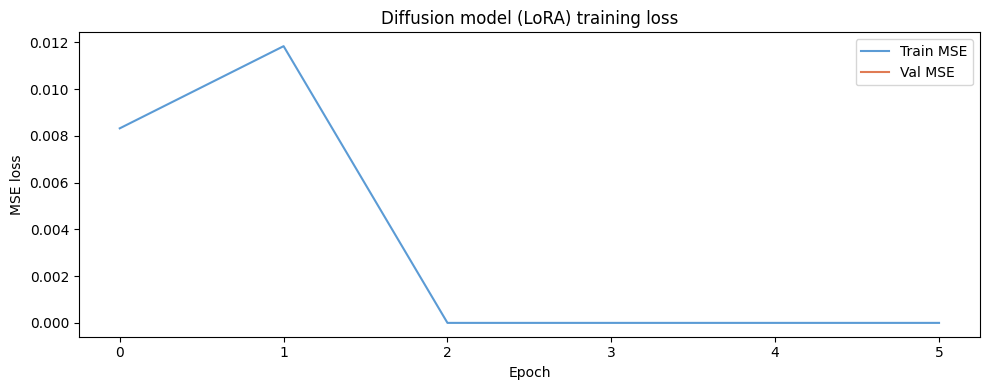

Loss log saved.


In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, label='Train MSE', color='#5b9bd5')
ax.plot(val_losses,   label='Val MSE',   color='#e07b54')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE loss')
ax.set_title('Diffusion model (LoRA) training loss')
ax.legend()
plt.tight_layout()
fig.savefig(LOG_DIR / 'figures' / 'lora_loss_curve.png', dpi=150)
plt.show()

with open(LOG_DIR / 'lora_training_log.json', 'w') as f:
    json.dump({'train_losses': train_losses, 'val_losses': val_losses}, f, indent=2)
print('Loss log saved.')


## 9 · Inference — hybrid DDPM / DDIM decode

This implements the full anomaly detection pipeline described in the overview.

### `ddim_encode`
Runs the *deterministic* DDIM forward process from `t=0` to `t=L` in the masked
region only. Unmasked pixels keep their original values.

### `hybrid_decode`
Runs reverse diffusion from `t=L` to `t=0`:
- **Inside mask** (`M=1`): DDPM step — stochastic, allows the model to
  replace pathological content with healthy anatomy
- **Outside mask** (`M=0`): DDIM step — deterministic, preserves the
  original healthy-looking anatomy exactly

### `anomaly_map`
Pixel-wise absolute difference `|x₀ − x̂₀|` between original and reconstruction.

In [13]:
@torch.no_grad()
def ddim_encode(x0: torch.Tensor, mask: torch.Tensor,
                scheduler: DDIMScheduler, n_steps: int = 50,
                encode_timestep: int = 500) -> torch.Tensor:
    """
    DDIM forward encode: x0 -> x_L in the masked region.

    Parameters
    ----------
    x0              : (1,1,256,256)  input slice on DEVICE
    mask            : (1,1,256,256)  binary mask, 1=pathology region
    scheduler       : DDIMScheduler
    n_steps         : number of DDIM steps for encoding
    encode_timestep : target noise level L (0 to T-1)

    Returns
    -------
    x_L : (1,1,256,256)  noised image at timestep L
    """
    # Direct forward process: add noise to encode_timestep using scheduler
    noise = torch.randn_like(x0)
    t_tensor = torch.tensor([encode_timestep], device=x0.device).long()
    x_noised = scheduler.add_noise(x0, noise, t_tensor)

    # Apply only in masked region; keep original elsewhere
    x_L = x0 * (1 - mask) + x_noised * mask
    return x_L


@torch.no_grad()
def hybrid_decode(x_L: torch.Tensor, x0_orig: torch.Tensor,
                  mask: torch.Tensor,
                  unet: nn.Module,
                  ddpm_sched: DDPMScheduler,
                  ddim_sched: DDIMScheduler,
                  start_t: int = 500,
                  n_ddim_steps: int = 50) -> torch.Tensor:
    """
    Hybrid DDPM/DDIM reverse decode from t=start_t -> t=0.

    Inside  mask (M=1) : DDPM step  — stochastic, allows healthy regeneration
    Outside mask (M=0) : DDIM step  — deterministic, preserves healthy anatomy

    Returns
    -------
    x_hat : (1,1,256,256)  healthy reconstruction
    """
    unet.eval()
    ddim_sched.set_timesteps(n_ddim_steps)

    # Filter timesteps to those <= start_t
    timesteps = [t for t in ddim_sched.timesteps if t <= start_t]

    x = x_L.clone()

    for t_val in timesteps:
        t_batch = torch.tensor([t_val], device=x.device).long()

        noise_pred = unet(x, t_batch)

        ddpm_out = ddpm_sched.step(noise_pred, t_val, x)
        x_ddpm   = ddpm_out[0]
        ddim_out = ddim_sched.step(noise_pred, t_val, x)
        x_ddim   = ddim_out[0]

        # Blend: mask region uses DDPM, rest uses DDIM
        x = x_ddim * (1 - mask) + x_ddpm * mask

        # repaste clean original (noised to current t) outside mask
        t_tensor = torch.tensor([t_val], device=x.device).long()
        x_orig_t = ddpm_sched.add_noise(x0_orig, torch.randn_like(x0_orig), t_tensor)
        x        = x_orig_t * (1 - mask) + x * mask
    return x.clamp(0.0, 1.0)


def anomaly_map(x0: torch.Tensor, x_hat: torch.Tensor,
                smooth_sigma: float = 2.0) -> torch.Tensor:
    """
    Compute pixel-wise anomaly score |x0 - x_hat|.
    Optionally smooth with a Gaussian kernel (sigma in pixels).
    Returns a (1,1,256,256) float32 tensor on CPU.
    """
    diff = (x0 - x_hat).abs().cpu()
    if smooth_sigma > 0:
        # approximate Gaussian with a separable box filter
        k = max(3, int(smooth_sigma * 3) | 1)   # odd kernel size
        pad = k // 2
        kernel = torch.ones(1, 1, 1, k) / k
        diff = F.conv2d(F.conv2d(diff, kernel, padding=(0, pad)),
                        kernel.transpose(-1, -2), padding=(pad, 0))
    return diff

print('Inference functions defined.')


Inference functions defined.


## 10 · Demo inference on a validation slice

Since we have no ACAT classifier yet, we use a **synthetic centre mask**
(a 64×64 square in the middle of the image) to demonstrate the pipeline.
Replace this mask with the ACAT saliency output for real anomaly detection.

12:57:01 | DEBUG | locator: <matplotlib.ticker.AutoLocator object at 0x7b7ac405e4e0>


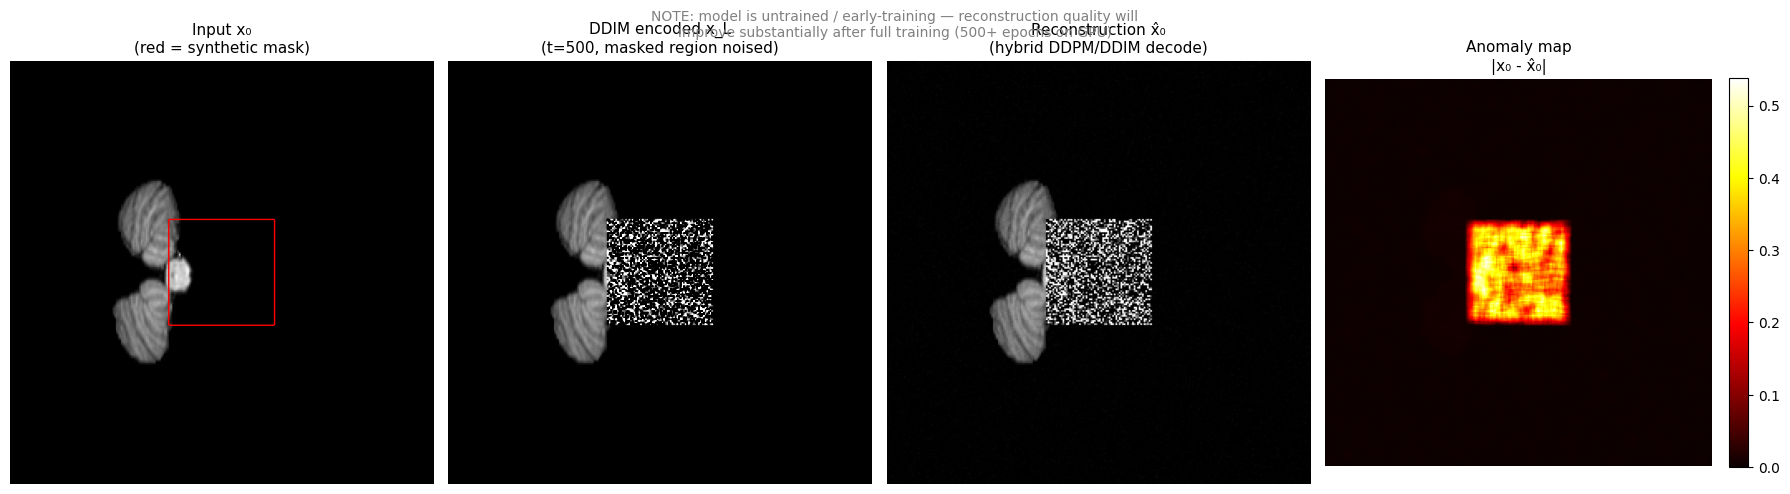

In [15]:
# ── pick one val slice ──────────────────────────────────────────────────
val_batch = next(iter(val_loader))
x0_demo   = val_batch[0:1].to(DEVICE)   # (1, 1, 256, 256)

# ── synthetic mask: 64x64 centre square ─────────────────────────────────
mask_demo = torch.zeros_like(x0_demo)
mask_demo[:, :, 96:160, 96:160] = 1.0   # centre 64x64

ENCODE_T  = 500   # how far to encode (noise level)
N_STEPS   = 50    # DDIM steps for decode

# ── run pipeline ────────────────────────────────────────────────────────
x_L    = ddim_encode(x0_demo, mask_demo, ddim_scheduler,
                     encode_timestep=ENCODE_T)

x_hat  = hybrid_decode(x_L, x0_demo, mask_demo,
                       unet, ddpm_scheduler, ddim_scheduler,
                       start_t=ENCODE_T, n_ddim_steps=N_STEPS)
a_map  = anomaly_map(x0_demo, x_hat, smooth_sigma=2.0)

# ── visualise ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(x0_demo[0, 0].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
axes[0].contour(mask_demo[0, 0].cpu().numpy(), levels=[0.5], colors='red', linewidths=1)
axes[0].set_title('Input x₀\n(red = synthetic mask)', fontsize=11)

axes[1].imshow(x_L[0, 0].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
axes[1].set_title(f'DDIM encoded x_L\n(t={ENCODE_T}, masked region noised)', fontsize=11)

axes[2].imshow(x_hat[0, 0].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
axes[2].set_title('Reconstruction x̂₀\n(hybrid DDPM/DDIM decode)', fontsize=11)

im = axes[3].imshow(a_map[0, 0].numpy(), cmap='hot', vmin=0)
axes[3].set_title('Anomaly map\n|x₀ - x̂₀|', fontsize=11)
fig.colorbar(im, ax=axes[3], fraction=0.046, pad=0.04)

for ax in axes:
    ax.axis('off')

fig.suptitle(
    'NOTE: model is untrained / early-training — reconstruction quality will\n'
    'improve substantially after full training (500+ epochs on GPU)',
    fontsize=10, color='gray'
)
plt.tight_layout()
fig.savefig(LOG_DIR / 'figures' / 'demo_anomaly_pipeline.png', dpi=150)
plt.show()


## 11 · Checkpoint utilities

Two saving strategies:
- **Full checkpoint** — entire model state (needed to resume training)
- **LoRA-only** — only the A/B matrices (~few MB). Load these on top of a
  freshly instantiated base model for inference.

In [ ]:
def save_lora_checkpoint(unet, epoch, path):
    """Save only LoRA weights + training metadata."""
    torch.save({
        'epoch'     : epoch,
        'lora_r'    : LORA_RANK,
        'lora_alpha': LORA_ALPHA,
        'lora_state': lora_state_dict(unet),
    }, path)


def load_lora_checkpoint(unet, path):
    """Load LoRA weights into an existing model (base weights unchanged)."""
    ckpt = torch.load(path, map_location='cpu')
    missing, unexpected = unet.load_state_dict(ckpt['lora_state'], strict=False)
    lora_keys = [k for k in ckpt['lora_state']]
    print(f'Loaded {len(lora_keys)} LoRA tensors from epoch {ckpt["epoch"]}')
    if unexpected:
        print(f'Unexpected keys: {unexpected[:5]}')
    return ckpt['epoch']


# Save final LoRA checkpoint
final_lora_path = CKPT_DIR / 'lora_weights_final.pt'
save_lora_checkpoint(unet, N_EPOCHS, final_lora_path)
print(f'LoRA weights saved to {final_lora_path}')
print(f'File size : {final_lora_path.stat().st_size / 1024:.1f} KB')


## 12 · Next steps

| Step | What to do |
|------|------------|
| **Train longer** | 500–1000 epochs on GPU; monitor val MSE convergence |
| **ACAT classifier** | Train or plug in the saliency/classifier to generate real pathology masks |
| **Tune encode depth** | Try `ENCODE_T` in {250, 500, 750} — higher = more freedom to edit, lower = more preservation |
| **Tune LoRA rank** | `r=4` is conservative; try `r=8` or `r=16` if val loss plateaus |
| **Evaluate anomaly map** | Threshold `a_map` and compute Dice/AUC against BraTS segmentation masks |
| **Multi-step encode** | For smoother masks, run DDIM encode iteratively rather than one-shot |
